In [ ]:
#!pip install shap
#!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
import warnings
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, matthews_corrcoef
from sklearn.metrics import *
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import plotly.express as px
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Cardiovascular_Disease_Dataset.csv")
df

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,9949544,48,1,2,139,349,0,2,183,1,5.6,2,2,1
996,9953423,47,1,3,143,258,1,1,98,1,5.7,1,0,0
997,9965859,69,1,0,156,434,1,0,196,0,1.4,3,1,1
998,9988507,45,1,1,186,417,0,1,117,1,5.9,3,2,1


In [ ]:
df = df.drop(columns=["patientid"], errors='ignore')
X = df.drop(columns=["target"])
y = df["target"]

In [ ]:
df['target'].value_counts()

target
1    580
0    420
Name: count, dtype: int64

In [ ]:
df.isna().sum()

age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   gender             1000 non-null   int64  
 2   chestpain          1000 non-null   int64  
 3   restingBP          1000 non-null   int64  
 4   serumcholestrol    1000 non-null   int64  
 5   fastingbloodsugar  1000 non-null   int64  
 6   restingrelectro    1000 non-null   int64  
 7   maxheartrate       1000 non-null   int64  
 8   exerciseangia      1000 non-null   int64  
 9   oldpeak            1000 non-null   float64
 10  slope              1000 non-null   int64  
 11  noofmajorvessels   1000 non-null   int64  
 12  target             1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 101.7 KB


In [ ]:
df.describe()

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


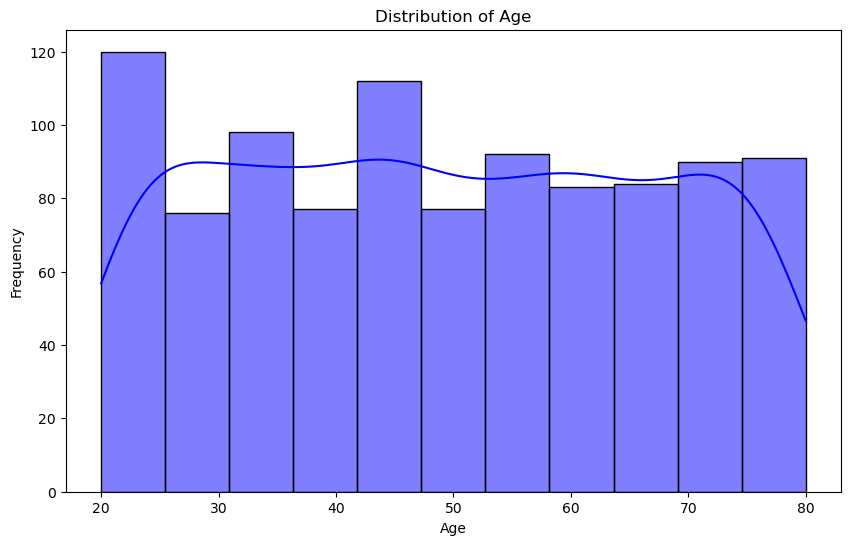

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

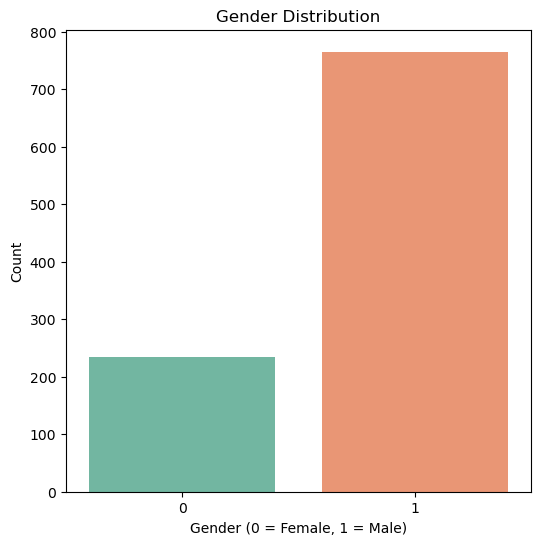

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.show()

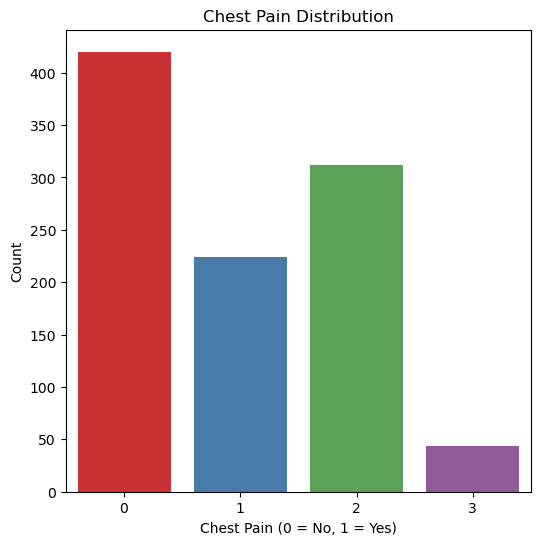

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='chestpain', data=df, palette='Set1')
plt.title('Chest Pain Distribution')
plt.xlabel('Chest Pain (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

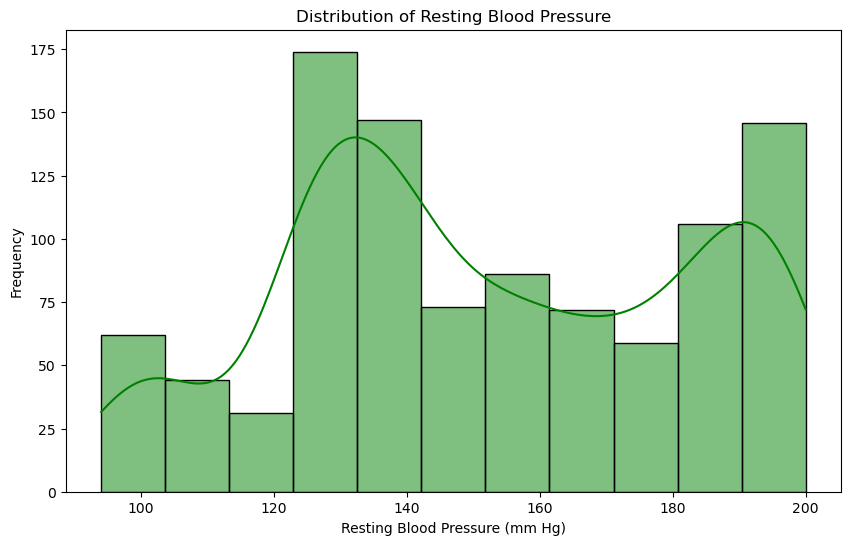

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['restingBP'], kde=True, color='green')
plt.title('Distribution of Resting Blood Pressure')
plt.xlabel('Resting Blood Pressure (mm Hg)')
plt.ylabel('Frequency')
plt.show()

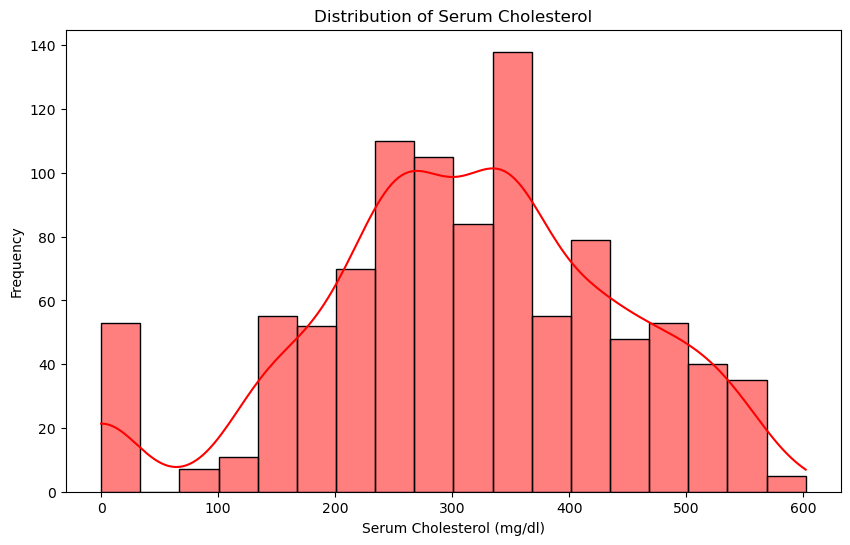

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['serumcholestrol'], kde=True, color='red')
plt.title('Distribution of Serum Cholesterol')
plt.xlabel('Serum Cholesterol (mg/dl)')
plt.ylabel('Frequency')
plt.show()

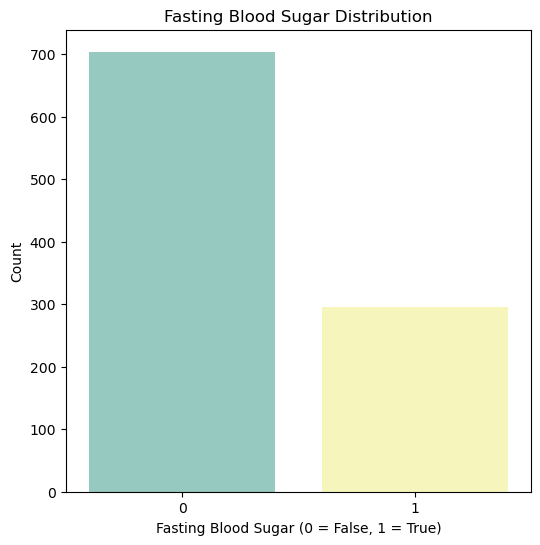

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='fastingbloodsugar', data=df, palette='Set3')
plt.title('Fasting Blood Sugar Distribution')
plt.xlabel('Fasting Blood Sugar (0 = False, 1 = True)')
plt.ylabel('Count')
plt.show()


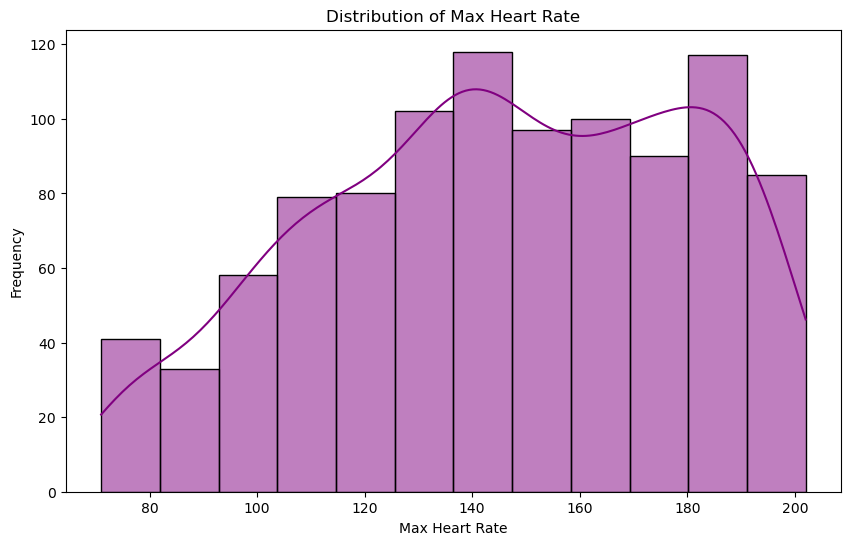

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['maxheartrate'], kde=True, color='purple')
plt.title('Distribution of Max Heart Rate')
plt.xlabel('Max Heart Rate')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.info()
#Every column is numerical so we need no label encode

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   gender             1000 non-null   int64  
 2   chestpain          1000 non-null   int64  
 3   restingBP          1000 non-null   int64  
 4   serumcholestrol    1000 non-null   int64  
 5   fastingbloodsugar  1000 non-null   int64  
 6   restingrelectro    1000 non-null   int64  
 7   maxheartrate       1000 non-null   int64  
 8   exerciseangia      1000 non-null   int64  
 9   oldpeak            1000 non-null   float64
 10  slope              1000 non-null   int64  
 11  noofmajorvessels   1000 non-null   int64  
 12  target             1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 101.7 KB


In [ ]:
#Unsupervised Learning
num_clusters = 3  # Low, Medium, High risk
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df["Risk_Category"] = kmeans.fit_predict(X)

In [ ]:
df

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target,Risk_Category
0,53,1,2,171,0,0,1,147,0,5.3,3,3,1,1
1,40,1,0,94,229,0,1,115,0,3.7,1,1,0,0
2,49,1,2,133,142,0,0,202,1,5.0,1,0,0,1
3,43,1,0,138,295,1,1,153,0,3.2,2,2,1,0
4,31,1,1,199,0,0,2,136,0,5.3,3,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,48,1,2,139,349,0,2,183,1,5.6,2,2,1,0
996,47,1,3,143,258,1,1,98,1,5.7,1,0,0,0
997,69,1,0,156,434,1,0,196,0,1.4,3,1,1,2
998,45,1,1,186,417,0,1,117,1,5.9,3,2,1,2


In [ ]:
df['Risk_Category'].value_counts()

Risk_Category
0    523
2    295
1    182
Name: count, dtype: int64

In [ ]:
centroids = kmeans.cluster_centers_
sorted_centroids = np.argsort(np.sum(centroids, axis=1))  # Sort clusters
risk_labels = {sorted_centroids[i]: label for i, label in enumerate(["Low", "Medium", "High"])}
df["Risk_Category"] = df["Risk_Category"].map(risk_labels)

In [ ]:
df['Risk_Category'].value_counts()
# 0->Medium Risk
# 1->High Risk
# 2->Low Risk

Risk_Category
Medium    523
High      295
Low       182
Name: count, dtype: int64

In [ ]:
# df['Risk_Category'].replace(['Low','Medium','High'],[0,1,2],inplace=True)
# df['Risk_Category'].value_counts()
# # 0->Low Risk
# # 1->Medium Risk
# # 2->High Risk

In [ ]:
X_train, X_test, y_train, y_test, train_risk, test_risk = train_test_split(
    X, y, df["Risk_Category"], test_size=0.2, random_state=42, stratify=df["Risk_Category"]
)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(verbose=-1, verbosity=-1),
    "CatBoost": CatBoostClassifier(verbose=0),
}

In [ ]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probs)
    mcc = matthews_corrcoef(y_test, predictions)
    acc = accuracy_score(y_test, predictions)
    pre = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    return f1, auc, mcc, acc, pre, rec


In [ ]:
trained_models = {}
results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    print("Training completed....Moving to the next model")
    f1, auc, mcc, acc,pre,rec = evaluate_model(model, X_test, y_test)
    trained_models[model_name] = model
    results[model_name] = {"F1 Score": f1, "AUC": auc, "MCC": mcc,"Accuracy":acc,"Precision":pre,"Recall":rec}

Training Logistic Regression...
Training completed....Moving to the next model
Training Random Forest...
Training completed....Moving to the next model
Training SVM...
Training completed....Moving to the next model
Training Decision Tree...
Training completed....Moving to the next model
Training Naive Bayes...
Training completed....Moving to the next model
Training XGBoost...
Training completed....Moving to the next model
Training LightGBM...
Training completed....Moving to the next model
Training CatBoost...
Training completed....Moving to the next model


In [ ]:
results

{'Logistic Regression': {'F1 Score': 0.9411764705882353,
  'AUC': 0.9783456486042692,
  'MCC': 0.8565501548781319,
  'Accuracy': 0.93,
  'Precision': 0.9180327868852459,
  'Recall': 0.9655172413793104},
 'Random Forest': {'F1 Score': 0.9871244635193134,
  'AUC': 0.9920977011494252,
  'MCC': 0.9692123940380459,
  'Accuracy': 0.985,
  'Precision': 0.9829059829059829,
  'Recall': 0.9913793103448276},
 'SVM': {'F1 Score': 0.8833333333333333,
  'AUC': 0.8852627257799671,
  'MCC': 0.7112844353836953,
  'Accuracy': 0.86,
  'Precision': 0.8548387096774194,
  'Recall': 0.9137931034482759},
 'Decision Tree': {'F1 Score': 0.9661016949152542,
  'AUC': 0.9556650246305419,
  'MCC': 0.9181395839231106,
  'Accuracy': 0.96,
  'Precision': 0.95,
  'Recall': 0.9827586206896551},
 'Naive Bayes': {'F1 Score': 0.9576271186440678,
  'AUC': 0.983784893267652,
  'MCC': 0.8974607644653828,
  'Accuracy': 0.95,
  'Precision': 0.9416666666666667,
  'Recall': 0.9741379310344828},
 'XGBoost': {'F1 Score': 0.98723404

In [ ]:
results_df = pd.DataFrame(results).T
results_df

,F1 Score,AUC,MCC,Accuracy,Precision,Recall
Logistic Regression,0.941176,0.978346,0.856550,0.930,0.918033,0.965517
Random Forest,0.987124,0.992098,0.969212,0.985,0.982906,0.991379
SVM,0.883333,0.885263,0.711284,0.860,0.854839,0.913793
Decision Tree,0.966102,0.955665,0.918140,0.960,0.950000,0.982759
Naive Bayes,0.957627,0.983785,0.897461,0.950,0.941667,0.974138
XGBoost,0.987234,0.990661,0.969524,0.985,0.974790,1.000000
LightGBM,0.987234,0.991585,0.969524,0.985,0.974790,1.000000
CatBoost,0.991453,0.988198,0.979615,0.990,0.983051,1.000000


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'Random Forest'),
  Text(2, 0, 'SVM'),
  Text(3, 0, 'Decision Tree'),
  Text(4, 0, 'Naive Bayes'),
  Text(5, 0, 'XGBoost'),
  Text(6, 0, 'LightGBM'),
  Text(7, 0, 'CatBoost')])

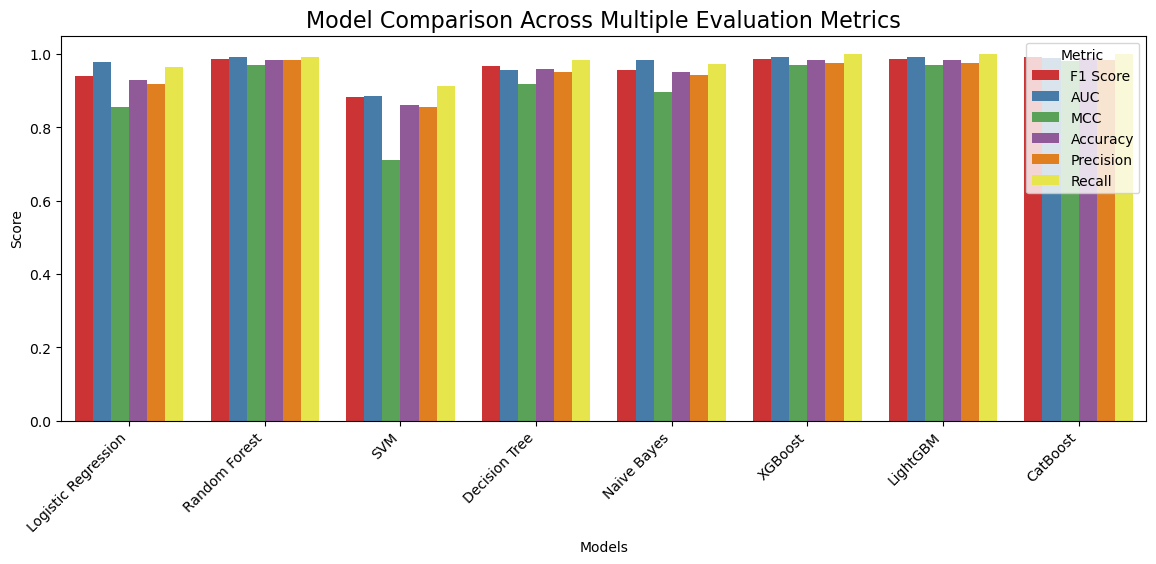

In [ ]:
results_melted = results_df.reset_index().melt(id_vars=["index"], value_vars=["F1 Score", "AUC", "MCC", "Accuracy", "Precision", "Recall"])
results_melted.columns = ["Model", "Metric", "Score"]

plt.figure(figsize=(14, 5))
sns.barplot(x="Model", y="Score", hue="Metric", data=results_melted, palette="Set1")

plt.title("Model Comparison Across Multiple Evaluation Metrics", fontsize=16)
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")

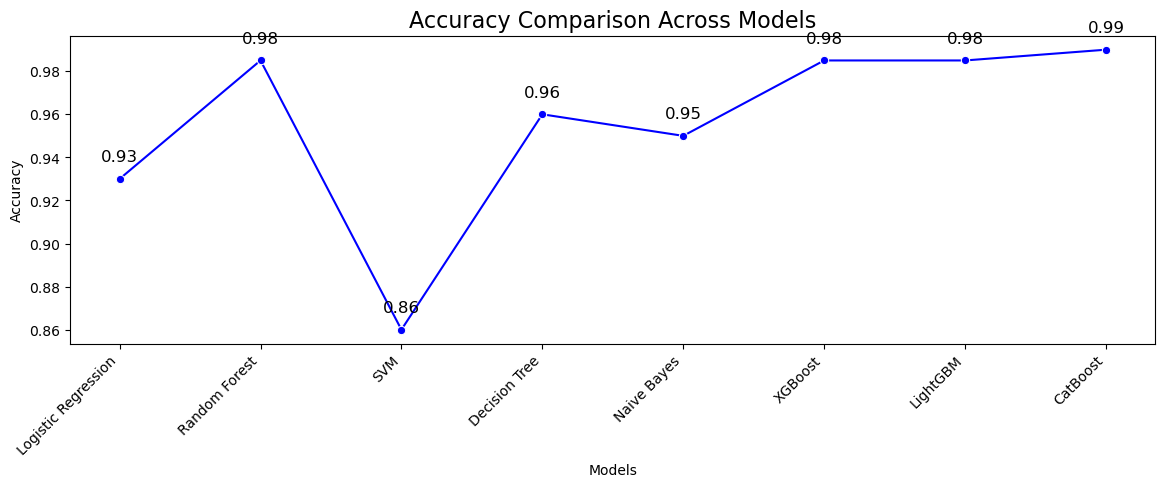

In [ ]:
plt.figure(figsize=(14, 4))
sns.lineplot(x=results_df.index, y=results_df["Accuracy"], marker='o', color='b')

plt.title("Accuracy Comparison Across Models", fontsize=16)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")

for i in range(len(results_df)):
    plt.text(i, results_df["Accuracy"].iloc[i] + 0.008,
             f'{results_df["Accuracy"].iloc[i]:.2f}',
             ha='center', fontsize=12)

In [ ]:
trained_models['Random Forest'].predict(pd.DataFrame(X_test.iloc[0]).T)

array([1], dtype=int64)

In [ ]:
kmeans.predict(pd.DataFrame(X_test.iloc[0]).T)

array([0])

In [ ]:
# dataset_description = {
#     "age": "Enter age in years (Numeric, e.g., 45)",
#     "gender": "Enter gender (1 = male, 0 = female) (Binary)",
#     "chestpain": "Enter chest pain type (0: typical angina, 1: atypical angina, 2: non-anginal pain, 3: asymptomatic)",
#     "restingBP": "Enter resting blood pressure in mmHg (Range: 94-200)",
#     "serumcholestrol": "Enter serum cholesterol in mg/dl (Range: 126-564)",
#     "fastingbloodsugar": "Enter fasting blood sugar (0 = false, 1 = true, > 120 mg/dl)",
#     "restingrelectro": "Enter resting electrocardiogram results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)",
#     "maxheartrate": "Enter maximum heart rate achieved (Range: 71-202)",
#     "exerciseangia": "Enter exercise-induced angina (0 = no, 1 = yes) (Binary)",
#     "oldpeak": "Enter ST depression (Range: 0-6.2)",
#     "slope": "Enter slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)",
#     "noofmajorvessels": "Enter number of major coronary vessels (Range: 0-3)"
# }

# print("Enter patient details:")
# patient_data = {}
# for feature in X.columns:
#     print(f"{dataset_description[feature]}")
#     patient_data[feature] = float(input(f"Enter {feature}: "))

# print("Please select the model for prediction:")
# print("Enter 'A' for Random Forest, 'B' for Decision Tree, 'C' for SVM, 'D' for Naive Bayes, 'E' for LightGBM, 'F' for XGBoost, 'G' for CatBoost, 'H' for LogisticRegression")
# chosen_model = input()
# patient_df = pd.DataFrame([patient_data], columns=X.columns)

dataset_description = {
    "age": ("Enter age in years (Numeric, e.g., 45)", lambda x: 0 < x < 150),
    "gender": ("Enter gender (1 = male, 0 = female) (Binary)", lambda x: x in [0, 1]),
    "chestpain": ("Enter chest pain type (0: typical angina, 1: atypical angina, 2: non-anginal pain, 3: asymptomatic)", lambda x: x in [0, 1, 2, 3]),
    "restingBP": ("Enter resting blood pressure in mmHg (Range: 94-200)", lambda x: 94 <= x <= 200),
    "serumcholestrol": ("Enter serum cholesterol in mg/dl (Range: 126-564)", lambda x: 126 <= x <= 564),
    "fastingbloodsugar": ("Enter fasting blood sugar (0 = false, 1 = true, > 120 mg/dl)", lambda x: x in [0, 1]),
    "restingrelectro": ("Enter resting electrocardiogram results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)", lambda x: x in [0, 1, 2]),
    "maxheartrate": ("Enter maximum heart rate achieved (Range: 71-202)", lambda x: 71 <= x <= 202),
    "exerciseangia": ("Enter exercise-induced angina (0 = no, 1 = yes) (Binary)", lambda x: x in [0, 1]),
    "oldpeak": ("Enter ST depression (Range: 0-6.2)", lambda x: 0 <= x <= 6.2),
    "slope": ("Enter slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)", lambda x: x in [1, 2, 3]),
    "noofmajorvessels": ("Enter number of major coronary vessels (Range: 0-3)", lambda x: 0 <= x <= 3)
}

print("Enter patient details:")
patient_data = {}
for feature in X.columns:
    description, valid_check = dataset_description[feature]

    while True:
        try:
            print(f"{description}")
            user_input = float(input(f"Enter {feature}: "))

            if valid_check(user_input):
                patient_data[feature] = user_input
                break
            else:
                print("Incorrect input. Please enter a value within the valid range.")
        except ValueError:
            print("Incorrect input. Please enter a valid number.")

#print("Please select the model for prediction:")
#print("Enter 'A' for Random Forest, 'B' for Decision Tree, 'C' for SVM, 'D' for Naive Bayes, 'E' for LightGBM, 'F' for XGBoost, 'G' for CatBoost, 'H' for LogisticRegression")
#chosen_model = input()
chosen_model='G'
patient_df = pd.DataFrame([patient_data], columns=X.columns)

Enter patient details:
Enter age in years (Numeric, e.g., 45)


Enter age:  23


Enter gender (1 = male, 0 = female) (Binary)


Enter gender:  1


Enter chest pain type (0: typical angina, 1: atypical angina, 2: non-anginal pain, 3: asymptomatic)


...

Enter slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)


Enter slope:  1


Enter number of major coronary vessels (Range: 0-3)


Enter noofmajorvessels:  1


Please select the model for prediction:


In [ ]:
risk_level_map={0:'Medium Risk',1:"High Risk",2:"Low Risk"}
risk_percentage_map = {2: "0-33%", 0: "34-66%", 1: "67-100%"}
model_map={'A':'Random Forest', 'B' : 'Decision Tree', 'C': 'SVM', 'D' : 'Naive Bayes', 'E' : 'LightGBM', 'F' : 'XGBoost','G' : 'CatBoost','H':'Logistic Regression'}
feature_statements = {
    "age": "The patient's age plays a significant role in increasing heart disease risk. As people age, the likelihood of heart disease increases.",
    "gender": "Gender is a contributing factor, with males generally having a higher risk of heart disease compared to females.",
    "chestpain": "Chest pain can be an indicator of heart disease, with patients reporting chest pain often experiencing coronary artery issues.",
    "restingBP": "Higher resting blood pressure is a major risk factor for heart disease. Consistently elevated blood pressure can damage the arteries over time.",
    "serumcholesterol": "High serum cholesterol levels contribute to the buildup of plaques in the arteries, increasing the risk of heart disease.",
    "fastingbloodsugar": "High fasting blood sugar levels can indicate insulin resistance, which is a risk factor for heart disease.",
    "restingrelectro": "Abnormalities in the electrocardiogram, such as ST-T wave changes, indicate an increased risk of heart disease.",
    "maxheartrate": "A lower maximum heart rate during exercise may indicate lower cardiovascular fitness, which can contribute to heart disease risk.",
    "exerciseangina": "The presence of exercise-induced angina increases the risk for heart disease, often indicating insufficient blood flow to the heart.",
    "oldpeak": "Elevated ST depression in the ECG during exercise is associated with higher heart disease risk.",
    "slope": "The slope of the peak exercise ST segment gives an indication of heart stress during exercise, with certain slopes indicating higher risk.",
    "noofmajorvessels": "The number of major coronary arteries with blockages directly correlates with heart disease severity, with more blocked vessels indicating a higher risk."
}
lifestyle_recommendations = {
    "age": [
        "Maintain a healthy weight through diet and exercise.",
        "Engage in regular physical activities to improve cardiovascular health.",
        "Get regular health checkups to monitor heart health.",
        "Consider stress management techniques, such as meditation or yoga.",
        "Avoid smoking and limit alcohol consumption to reduce heart disease risk."
    ],
    "gender": [
        "While gender is a factor, lifestyle modifications such as maintaining a healthy diet, exercising regularly, and avoiding smoking can significantly reduce heart disease risk.",
        "Ensure regular cardiovascular check-ups and manage stress levels to improve heart health.",
        "Adopt healthy habits, including controlling weight and keeping cholesterol levels in check."
    ],
    "chestpain": [
        "If you experience chest pain, it is important to consult a healthcare provider for further assessment and treatment.",
        "Manage stress effectively and practice relaxation techniques to reduce symptoms.",
        "Avoid strenuous activities until a healthcare provider gives you clearance for exercise.",
        "Adopt a heart-healthy diet, focusing on foods that support artery health."
    ],
    "restingBP": [
        "Reduce sodium intake by limiting processed and high-salt foods.",
        "Engage in regular cardiovascular exercise, such as walking or swimming.",
        "Avoid excessive alcohol consumption and reduce caffeine intake.",
        "Practice stress reduction techniques, such as deep breathing or meditation.",
        "Monitor blood pressure regularly and consult a healthcare provider if high."
    ],
    "serumcholesterol": [
        "Adopt a low-fat, high-fiber diet to help lower cholesterol levels.",
        "Increase physical activity to improve heart health and reduce cholesterol.",
        "Limit saturated fats and trans fats in the diet, focusing on healthy fats.",
        "Monitor cholesterol levels regularly to track improvements.",
        "Consider medications prescribed by a doctor if lifestyle changes are insufficient."
    ],
    "fastingbloodsugar": [
        "Follow a balanced diet rich in whole grains, vegetables, and lean proteins to manage blood sugar levels.",
        "Engage in regular physical activity to improve insulin sensitivity and help control blood sugar.",
        "Monitor blood sugar levels regularly and consult a healthcare provider to adjust your diet and medications if needed.",
        "Avoid excessive consumption of sugary foods and drinks.",
        "Reduce stress through relaxation techniques to help maintain stable blood sugar levels."
    ],
    "restingrelectro": [
        "If abnormalities are present, consult a healthcare provider to assess the severity of the issue and develop a treatment plan.",
        "Maintain a heart-healthy diet to support healthy cardiovascular function.",
        "Engage in regular physical activities, such as walking or swimming, to improve heart health.",
        "Monitor your health regularly to track changes in your cardiovascular function."
    ],
    "maxheartrate": [
        "Engage in regular aerobic exercise to improve cardiovascular fitness.",
        "Incorporate strength training exercises to boost overall fitness.",
        "Avoid excessive sedentary behavior and increase daily physical activity.",
        "Consider working with a fitness trainer to create a tailored exercise program.",
        "Track heart rate during exercise to ensure it stays within a healthy range."
    ],
    "exerciseangina": [
        "Consult a healthcare provider to assess heart health and develop a safe exercise plan.",
        "Begin with low-intensity exercises and gradually increase intensity as tolerated.",
        "Avoid overexertion during physical activities to prevent angina.",
        "Monitor symptoms during exercise and stop if any discomfort or pain occurs.",
        "Consider medications prescribed by a healthcare provider to manage symptoms."
    ],
    "oldpeak": [
        "Engage in aerobic exercises to improve heart health and reduce symptoms.",
        "Follow a balanced diet to improve overall heart health and reduce plaque buildup.",
        "Manage stress effectively with techniques like mindfulness and relaxation exercises.",
        "Regularly monitor heart health with a healthcare provider.",
        "Adhere to any prescribed treatments or medications to reduce cardiovascular risk."
    ],
    "slope": [
        "Adopt an exercise routine that includes both aerobic and strength training activities to improve heart function.",
        "Limit stress through regular relaxation techniques, such as yoga or meditation.",
        "Maintain a heart-healthy diet, rich in fiber and low in saturated fats.",
        "Monitor your cardiovascular health regularly with a healthcare provider.",
        "Avoid smoking and excessive alcohol consumption, which can worsen heart stress."
    ],
    "noofmajorvessels": [
        "Follow a heart-healthy diet that is low in saturated fats and cholesterol.",
        "Engage in regular cardiovascular exercise to improve heart health and reduce the risk of further blockage.",
        "Monitor cholesterol and blood pressure levels regularly.",
        "Consider medications as prescribed by a healthcare provider to manage coronary artery disease.",
        "Consult a healthcare provider for further assessment and possible interventions, such as angioplasty or bypass surgery."
    ]
}
hospitals=['SRM Global Hospitals, SRM Nagar Potheri, SRM Nagar, Chengalpattu', 'Apollo Hospitals, Greames Road, Chennai', 'SIMS Hospitals, Vadapalani, Chennai','Deepam Hospital, Tambaram, Chennai']


In [ ]:
disease_prediction= 'No' if trained_models[model_map[chosen_model]].predict(patient_df)[0]=='No' else 'Yes'
risk_prediction=kmeans.predict(patient_df)[0]
print("Disease Prediction: ",disease_prediction)
if disease_prediction=='Yes':
    print("We recommend visiting one of the following nearby hospitals:")
    for i, hospital in enumerate(hospitals, 1):
        print(f"{i}. {hospital}")
else:
    print("No cardiovascular disease detected.")

Disease Prediction:  Yes
We recommend visiting one of the following nearby hospitals:
1. SRM Global Hospitals, SRM Nagar Potheri, SRM Nagar, Chengalpattu
2. Apollo Hospitals, Greames Road, Chennai
3. SIMS Hospitals, Vadapalani, Chennai
4. Deepam Hospital, Tambaram, Chennai


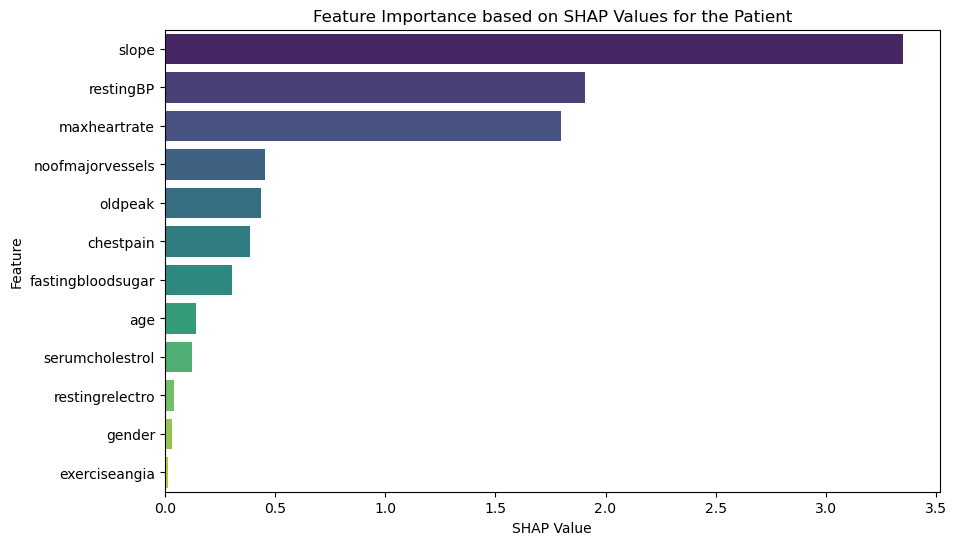

Top 4 features based on SHAP values: ['slope', 'restingBP', 'maxheartrate', 'noofmajorvessels']


In [ ]:
if isinstance(trained_models[model_map[chosen_model]], (XGBClassifier, LGBMClassifier, CatBoostClassifier,
                      RandomForestClassifier, DecisionTreeClassifier)):
    print(trained_models[model_map[chosen_model]])
    explainer_patient = shap.TreeExplainer(trained_models[model_map[chosen_model]])
elif isinstance(trained_models[model_map[chosen_model]], LogisticRegression):
    print(trained_models[model_map[chosen_model]])
    explainer_patient = shap.LinearExplainer(trained_models[model_map[chosen_model]], X_train)
else:
    print(trained_models[model_map[chosen_model]])
    explainer_patient = shap.KernelExplainer(trained_models[model_map[chosen_model]].predict_proba, shap.sample(X_train, 100))


shap_values_patient = explainer_patient.shap_values(patient_array)

shap_abs = np.abs(shap_values_patient).flatten()

# Ensure the number of SHAP values matches the number of features
num_features = X.shape[1]
if len(shap_abs) > num_features:
    shap_abs = shap_abs[:num_features]
elif len(shap_abs) < num_features:
    shap_abs = np.pad(shap_abs, (0, num_features - len(shap_abs)), 'constant')


feature_importance = pd.DataFrame({'Feature': X.columns, 'SHAP Value': shap_abs})
feature_importance = feature_importance.sort_values(by='SHAP Value', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='SHAP Value', y='Feature', data=feature_importance, palette='viridis')
plt.title("Feature Importance based on SHAP Values for the Patient")
plt.show()

top_4_features = feature_importance['Feature'].head(4).tolist()
print("Top 4 features based on SHAP values:", top_4_features)

In [ ]:
if risk_prediction == 2:
        risk_statement = "This patient has a 0-33% heart disease risk.\n It's a low risk of heart disease. Maintain a healthy lifestyle to keep your heart ingood shape! Regular exercise, a balanced diet, and routine check-ups will help you stay on track.\n"
elif risk_prediction == 0:
        risk_statement = "This patient has a 34-66% heart disease risk.\n It's a medium risk of heart disease. While there’s no immediate danger, it’s important to take preventive steps. Consider monitoring your diet, increasing physicalactivity, and consulting a doctor for personalized advice.\n"
else:
        risk_statement = "This patient has a 67-100% heart disease risk.\n It's a high risk of heart disease. Immediate lifestyle changes and medical consultation are strongly recommended. Focus on managing key risk factors such as cholesterol, blood pressure, and stress levels. Seek medical guidance at the earliest.\n"
risk_factors = []
for feature in top_4_features:
    if feature in feature_statements:
        risk_factors.append(feature_statements[feature])
lifestyle_suggestions = []
for feature in top_4_features:
    if feature in lifestyle_recommendations:
        lifestyle_suggestions.extend(lifestyle_recommendations[feature])
final_statement =  risk_statement + " " + " ".join(risk_factors) + " Proper lifestyle changes are recommended. \n\n"
final_statement += "Here are some lifestyle recommendations based on the influencing factors causing the issue : \n\n" + "\n".join(lifestyle_suggestions)
print(final_statement)

This patient has a 67-100% heart disease risk.
 It's a high risk of heart disease. Immediate lifestyle changes and medical consultation are strongly recommended. Focus on managing key risk factors such as cholesterol, blood pressure, and stress levels. Seek medical guidance at the earliest.
 The slope of the peak exercise ST segment gives an indication of heart stress during exercise, with certain slopes indicating higher risk. Higher resting blood pressure is a major risk factor for heart disease. Consistently elevated blood pressure can damage the arteries over time. A lower maximum heart rate during exercise may indicate lower cardiovascular fitness, which can contribute to heart disease risk. The number of major coronary arteries with blockages directly correlates with heart disease severity, with more blocked vessels indicating a higher risk. Proper lifestyle changes are recommended. 

Here are some lifestyle recommendations based on the influencing factors causing the issue : 

A

In [ ]:
feature_importance

,Feature,SHAP Value
10,slope,3.349121
3,restingBP,1.904835
7,maxheartrate,1.796284
11,noofmajorvessels,0.454859
9,oldpeak,0.438274
2,chestpain,0.386624
5,fastingbloodsugar,0.306954
0,age,0.139578
4,serumcholestrol,0.122118
6,restingrelectro,0.041201


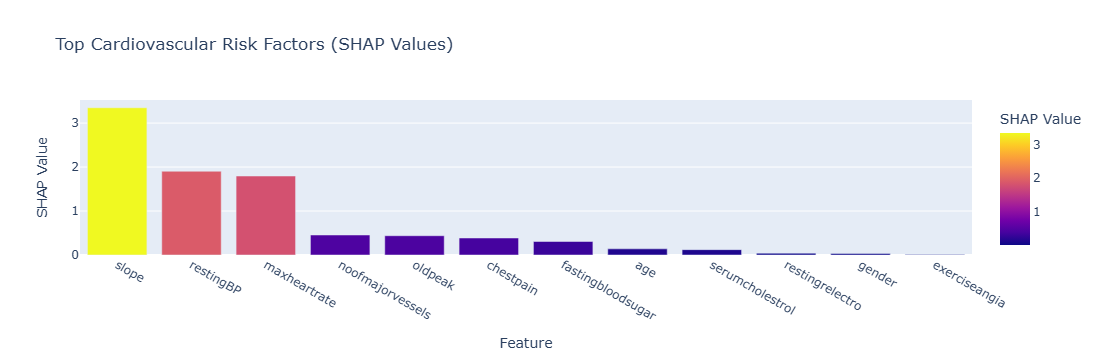

In [ ]:
feature_info = {
    "slope": "Slope of the peak exercise ST segment - Indicates heart stress during exercise.",
    "noofmajorvessels": "Number of major vessels colored by fluoroscopy - Identifies blockage.",
    "oldpeak": "ST depression induced by exercise - Shows abnormal heart response.",
    "maxheartrate": "Maximum Heart Rate Achieved - Indicates cardiac performance.",
    "age": "Age - A significant factor in cardiovascular disease risk.",
    "serumcholestrol": "Serum Cholesterol - High levels increase heart disease risk.",
    "restingBP": "Resting Blood Pressure - Elevated BP is a major risk factor.",
    "fastingbloodsugar": "Fasting Blood Sugar - High sugar levels link to heart issues.",
    "exerciseangia": "Exercise-Induced Angina - Chest pain triggered by physical activity.",
    "restingrelectro": "Resting Electrocardiographic Results - Detects electrical heart issues.",
    "gender": "Gender - Some cardiovascular risks vary between males and females.",
    "chestpain": "Chest Pain Type - Different types indicate varying levels of risk."
}
fig = px.bar(
    feature_importance,
    x="Feature",
    y="SHAP Value",
    title="Top Cardiovascular Risk Factors (SHAP Values)",
    color="SHAP Value",
    hover_data=["Feature"]
)

fig.for_each_trace(lambda t: t.update(hovertemplate='%{x}<br>SHAP Value: %{y}'))
fig.show()



In [ ]:
def display_feature_info(feature_name):
    info = feature_info.get(feature_name, "No additional information available.")
    print(f"\n**{feature_name.capitalize()}**: {info}\n")

while True:
    feature = input("Enter a feature name to know more (or type 'exit' to quit): ").strip().lower()
    if feature == 'exit':
        break
    if feature in feature_info:
        display_feature_info(feature)
    else:
        print("Feature not found. Please try again.")

Enter a feature name to know more (or type 'exit' to quit):  slope



**Slope**: Slope of the peak exercise ST segment - Indicates heart stress during exercise.



Enter a feature name to know more (or type 'exit' to quit):  age



**Age**: Age - A significant factor in cardiovascular disease risk.



Enter a feature name to know more (or type 'exit' to quit):  exit


In [ ]:
health_tips = {
    "slope": "Maintain an active lifestyle with regular aerobic exercises like walking or cycling.",
    "noofmajorvessels": "Consult a cardiologist to assess the severity of blockages and consider lifestyle changes.",
    "oldpeak": "Practice stress management techniques like meditation and reduce sodium intake.",
    "maxheartrate": "Incorporate heart rate monitoring during workouts and maintain a target heart rate.",
    "age": "Regular check-ups and a balanced diet are crucial as age increases cardiovascular risk.",
    "serumcholestrol": "Follow a heart-healthy diet with low saturated fats and include fiber-rich foods.",
    "restingBP": "Monitor blood pressure regularly and reduce salt intake to maintain optimal levels.",
    "fastingbloodsugar": "Maintain balanced blood sugar through a low-glycemic diet and regular physical activity.",
    "exerciseangia": "Engage in moderate, supervised physical activity and consult a specialist if needed.",
    "restingrelectro": "Regular ECG screenings and maintaining a healthy lifestyle are recommended.",
    "gender": "Be aware of gender-specific cardiovascular risks and take preventive measures.",
    "chestpain": "Seek immediate medical attention if experiencing unusual chest pain or discomfort."
}
health_tips_df = feature_importance.sort_values(by="SHAP Value", ascending=False)
top_n = 5
top_features = health_tips_df.head(top_n)["Feature"].tolist()

print("💡 Top Risk Factors and Personalized Health Tips 💡\n")
for feature in top_features:
    tip = health_tips.get(feature, "No specific tip available.")
    print(f"🩺 {feature.capitalize()}: {tip}\n")

💡 Top Risk Factors and Personalized Health Tips 💡

🩺 Slope: Maintain an active lifestyle with regular aerobic exercises like walking or cycling.

🩺 Restingbp: Monitor blood pressure regularly and reduce salt intake to maintain optimal levels.

🩺 Maxheartrate: Incorporate heart rate monitoring during workouts and maintain a target heart rate.

🩺 Noofmajorvessels: Consult a cardiologist to assess the severity of blockages and consider lifestyle changes.

🩺 Oldpeak: Practice stress management techniques like meditation and reduce sodium intake.

